In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df=pd.read_csv("/content/drive/MyDrive/Machine Learning - 1/height-weight.csv")

In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


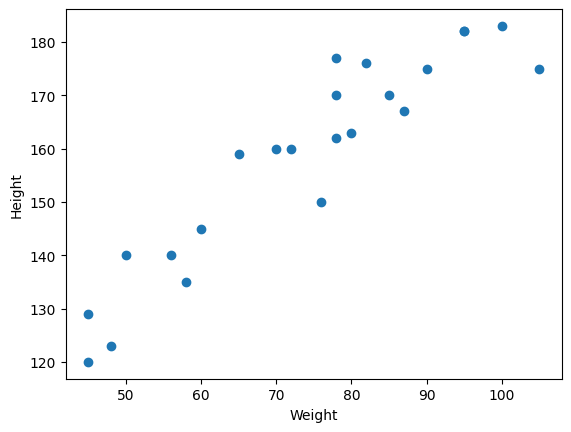

In [5]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()


## def corr(method: CorrelationMethod='pearson', min_periods: int=1, numeric_only: bool=False) -> DataFrame


Compute pairwise correlation of columns, excluding NA/null values.

Parameters

method : {'pearson', 'kendall', 'spearman'} or callable
    Method of correlation:


- pearson : standard correlation coefficient

- kendall : Kendall Tau correlation coefficient

- spearman : Spearman rank correlation

callable: callable with input two 1d ndarrays
and returning a float. Note that the returned matrix from corr
will have 1 along the diagonals and will be symmetric
regardless of the callable's behavior.
min_periods : int, optional
Minimum number of observations required per pair of columns
to have a valid result. Currently only available for Pearson
and Spearman correlation.
numeric_only : bool, default False
Include only float, int or boolean data.


Returns

DataFrame
    Correlation matrix.

In [6]:
# finding the correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


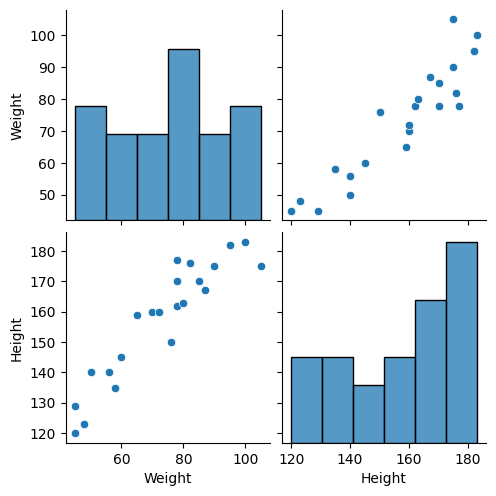

In [7]:
sns.pairplot(df)

In [8]:
# Dividing my data into dependent and independent features
X=df[["Weight"]] # independent variables should be in 2d array or dataframe
y=df["Height"] # dependent varibles should in series or 1D form

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#def train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
#The random_state parameter in Scikit-learn's train_test_split function acts as a seed for the random number generator used to shuffle your data.

**Now each feature can have different dimentions like kg dollar etc so we need to standardize it for better model generatation**

### Standardization (transforming features to have a mean of \(0\) and a variance/standard deviation of \(1\)) is crucial in linear regression to prevent optimization instability, ensure fair feature importance comparisons, and enable proper regularization


### If you are using iterative optimization algorithms like Gradient Descent to find your optimal model weights, unscaled features can cause severe headaches:
- Uneven Cost Contours: Features with wildly different ranges create "elongated, oval" loss contours rather than symmetric bowls.
- Optimization Instability: The algorithm may oscillate wildly or diverge along axes with larger scales, while moving agonizingly slowly along axes with smaller scales.
- Universal Learning Rates: Standardization ensures all features share the same scale, allowing the model to converge efficiently using a single, uniform learning rate

In [10]:
# Applying standardization
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
# Since we will using the same value of mu and sigma for transforming test data so we just user transform function only
# the reason we do this is because of data leakge , we dont want our test data to know these value

Z-score calculation (standardization) often used alongside linear regression, the value \(z\) is calculated using the following formula:\(z=\frac{x-\mu }{\sigma }\)Key Components of the Calculation:\(x\): The original feature value.\(\mu \) (mu): The mean of the training samples for that feature.\(\sigma \) (sigma): The standard deviation of the training samples.How fit_transform Handles It:fit(): The scaler calculates the mean (\(\mu \)) and standard deviation (\(\sigma \)) from your training data and stores them.transform(): The scaler applies the \(z\) formula to every data point using those stored parameters.fit_transform(): Performs both steps in one go, first "learning" the statistics and then immediately applying the transformation.

In [11]:
# apply linear regression algorithm
reg=LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [12]:
# Show the co efficient (Slope of the best fit line)
reg.coef_

array([17.03440872])

In [13]:
# Show the intercept
reg.intercept_

np.float64(157.5)

In [14]:
''' Y = β 0 + β 1 X 1 is the equation
where β 0 is the intercept and β 1 is the slope of the line.
'''

' Y = β 0 + β 1 X 1 is the equation\nwhere β 0 is the intercept and β 1 is the slope of the line.\n'

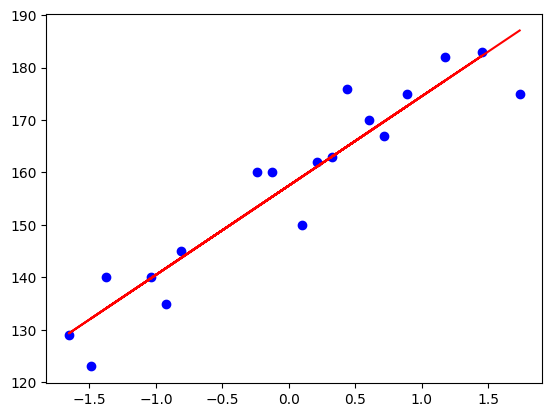

In [15]:
# plot the training data
plt.scatter(X_train,y_train,color='blue',label='Training Data')
# plot the regression line
plt.plot(X_train,reg.predict(X_train),color='red',label='Regression Line')


In [16]:
# Prediction for test data
# Equation  [ y_pred=157.6 + 17.03(x_test) ]

y_pred=reg.predict(X_test)

In [17]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [18]:
print(mse)
print(mae)
print(r2)

109.77592599051664
9.822657814519232
0.776986986042344


In [24]:
#OLS Linear Regression
import statsmodels.api as sm

model=sm.OLS(y_train,X_train).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Sat, 16 May 2026   Prob (F-statistic):                       0.661
Time:                        10:28:21   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [31]:
prediction=model.predict(y_test)

In [32]:
prediction

,0
15,3015.090343
9,2895.849482
0,2044.129046
8,3100.262387
17,2708.470986


In [34]:
reg.predict(scaler.transform([[72]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.30639545])

In [35]:
import pickle

In [37]:
with open('/content/drive/MyDrive/Machine Learning - 1/linear_regression_model.pkl', 'wb') as file:
    pickle.dump(reg, file)

In [38]:
with open('/content/drive/MyDrive/Machine Learning - 1/linear_regression_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [39]:
loaded_model.predict(scaler.transform([[61]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([144.71289053])